# Internship Project — Week 1

# Project Title: House Price Prediction

## Step 1: Import Libraries

In [26]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# Task 1: Data Loading & Exploration

## Step 2: Load Dataset

In [27]:
df = pd.read_csv("Housing.csv")

## Step 3: Display First 10 Rows

In [28]:
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


## Step 4: Check Dataset Shape

In [29]:
df.shape

(545, 13)

## Step 5: Dataset Information

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


## Step 6: Missing Values

In [31]:
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


## Step 7: Target and Features

In [32]:
y = df['price']

In [33]:
X = df.drop('price', axis=1)

# Task 2: Data Cleaning

## Step 8: Check Duplicates

In [34]:
df.duplicated().sum()

np.int64(0)

In [35]:
df.drop_duplicates(inplace=True)

## Step 9: Convert Categorical Columns

In [36]:
df = pd.get_dummies(df, drop_first=True)

In [37]:
df.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


# Task 3: Model Building

## Step 10: Split Dataset

In [38]:
X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Step 11: Train Linear Regression

In [39]:
lr = LinearRegression()

lr.fit(X_train, y_train)

LinearRegression()

In [40]:
y_pred_lr = lr.predict(X_test)

## Step 12: Evaluate Linear Regression

In [41]:
mae_lr = mean_absolute_error(y_test, y_pred_lr)

rmse_lr = np.sqrt(
    mean_squared_error(y_test, y_pred_lr)
)

r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)
print("R2 Score:", r2_lr)

Linear Regression Results
MAE: 970043.4039201636
RMSE: 1324506.9600914386
R2 Score: 0.6529242642153184


## Step 13: Train Random Forest

In [42]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [43]:
y_pred_rf = rf.predict(X_test)

## Step 14: Evaluate Random Forest

In [44]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)

rmse_rf = np.sqrt(
    mean_squared_error(y_test, y_pred_rf)
)

r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)

Random Forest Results
MAE: 1021546.0353211008
RMSE: 1400565.9728553821
R2 Score: 0.611918531405699


## Step 15: Compare Models

In [45]:
comparison = pd.DataFrame({
    'Model':['Linear Regression','Random Forest'],
    'MAE':[mae_lr,mae_rf],
    'RMSE':[rmse_lr,rmse_rf],
    'R2 Score':[r2_lr,r2_rf]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.021546e+06,1.400566e+06,0.611919


# Task 4: Visualizations

## Chart 1: House Price Distribution

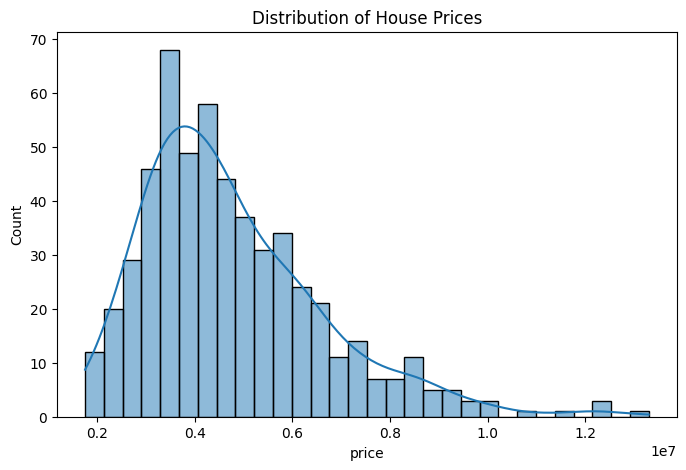

In [46]:
plt.figure(figsize=(8,5))

sns.histplot(df['price'],
             bins=30,
             kde=True)

plt.title("Distribution of House Prices")

plt.savefig("price_distribution.png")

plt.show()

## Chart 2: Correlation Heatmap

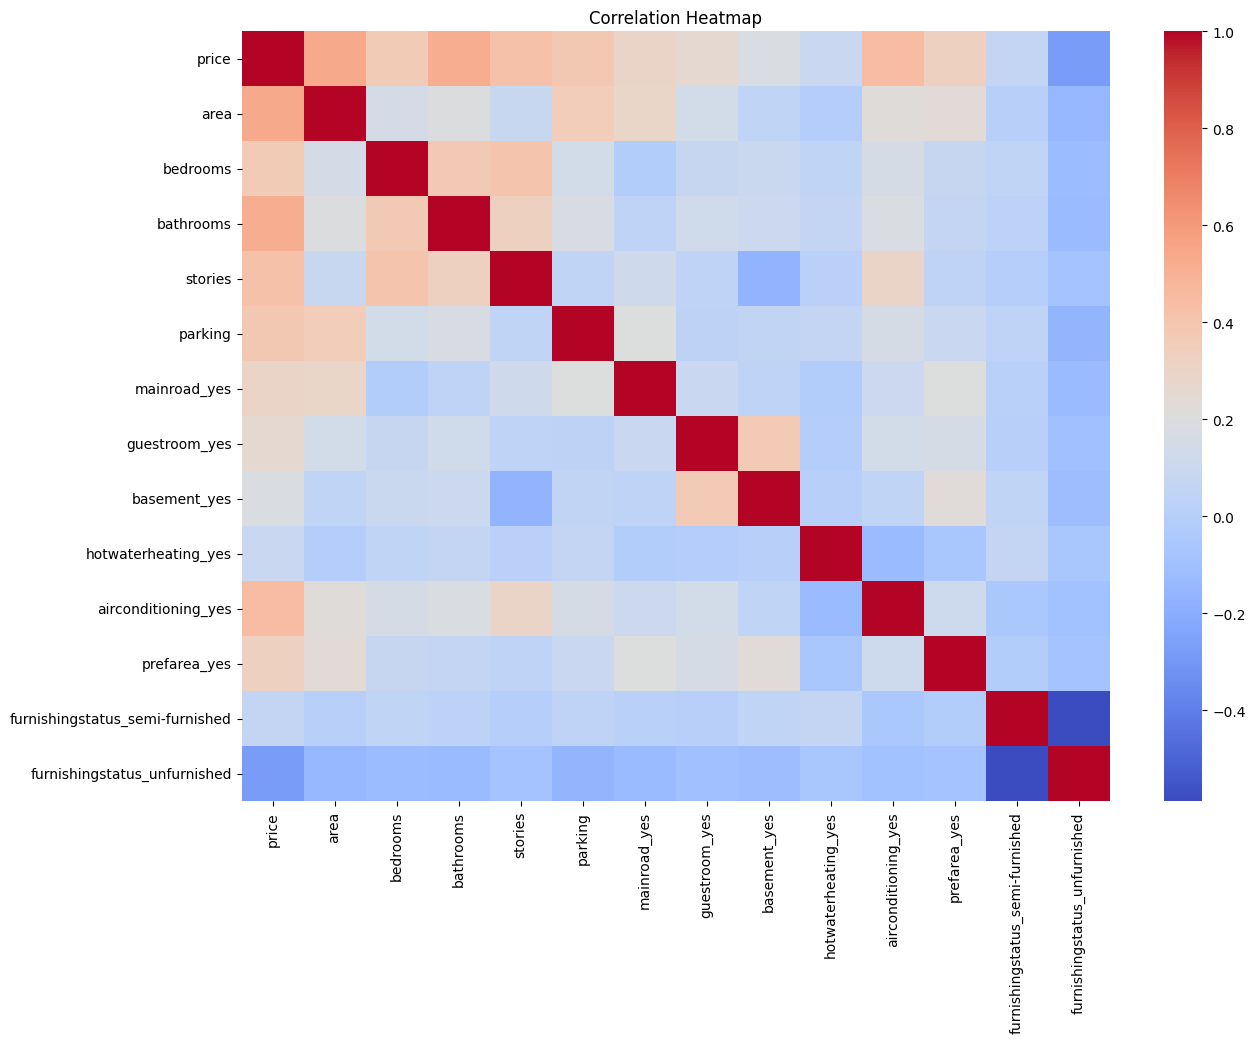

In [47]:
plt.figure(figsize=(14,10))

sns.heatmap(
    df.corr(),
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.savefig("correlation_heatmap.png")

plt.show()

## Chart 3: Actual vs Predicted Prices

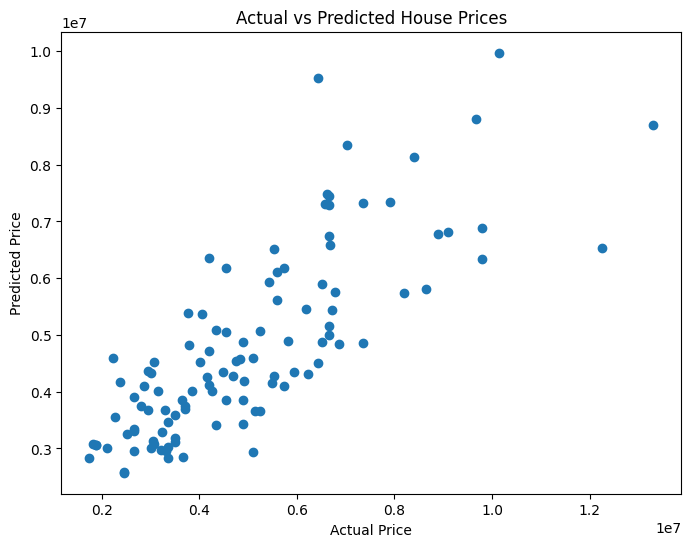

In [48]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred_rf
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted House Prices")

plt.savefig("actual_vs_predicted.png")

plt.show()

## Step 16: Feature Importance

In [49]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(10))

                         Feature  Importance
0                           area    0.468430
2                      bathrooms    0.151483
9            airconditioning_yes    0.062672
4                        parking    0.057455
3                        stories    0.057133
1                       bedrooms    0.048413
12  furnishingstatus_unfurnished    0.035011
7                   basement_yes    0.030823
10                  prefarea_yes    0.030689
8            hotwaterheating_yes    0.017226


# Task 5: Insights & Summary

This project focused on predicting house prices using various property characteristics available in the dataset. The data was cleaned, transformed, and analyzed to uncover patterns that influence housing costs. Two machine learning approaches, Linear Regression and Random Forest Regression, were implemented and evaluated. Based on the results, Linear Regression produced the most reliable predictions with an R² score of 0.653. The analysis highlighted that factors such as property size, number of bathrooms, parking capacity, and additional facilities contribute significantly to a home's market value. It was also observed that houses equipped with better amenities tend to be priced higher. These findings can help real estate professionals make more informed pricing decisions and provide accurate property valuations to customers.


## Step 17: Save Model

In [50]:
import pickle

pickle.dump(
    rf,
    open("house_price_model.pkl","wb")
)